## Step 1: Import Libraries

In [19]:
import os
import warnings
import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.utils import resample
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

print('All libraries imported!')

All libraries imported!


## Step 2: Set Dataset Paths

In [20]:
base_path = os.getcwd()
real_path = os.path.join(base_path, 'AUDIO', 'REAL')
fake_path = os.path.join(base_path, 'AUDIO', 'FAKE')

# Verify paths exist
assert os.path.exists(real_path), f' REAL folder not found: {real_path}'
assert os.path.exists(fake_path), f' FAKE folder not found: {fake_path}'

real_files = [f for f in os.listdir(real_path) if f.lower().endswith('.wav')]
fake_files = [f for f in os.listdir(fake_path) if f.lower().endswith('.wav')]

print(f' REAL audio files: {len(real_files)}')
print(f' FAKE audio files: {len(fake_files)}')
print(f' Total           : {len(real_files) + len(fake_files)}')

 REAL audio files: 61
 FAKE audio files: 301
 Total           : 362


##  Step 3: Feature Extraction

In [21]:
def extract_features(file_path):
    """
    Extracts 52 audio features for fake/real classification.
    Returns numpy array or None if file fails to load.
    """
    try:
        audio, sr = librosa.load(file_path, sr=16000, mono=True)

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc.T, axis=0)  

        centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
        centroid_mean = np.mean(centroid)

        bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
        bandwidth_mean = np.mean(bandwidth)

        rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
        rolloff_mean = np.mean(rolloff)

        flatness = librosa.feature.spectral_flatness(y=audio)
        flatness_mean = np.mean(flatness)

        zcr = librosa.feature.zero_crossing_rate(audio)
        zcr_mean = np.mean(zcr)

        rms = librosa.feature.rms(y=audio)
        rms_mean = np.mean(rms)
        rms_std  = np.std(rms)

        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)   

        feature_vector = np.concatenate([
            mfcc_mean,
            [centroid_mean, bandwidth_mean, rolloff_mean,
             flatness_mean, zcr_mean, rms_mean, rms_std],
            chroma_mean
        ])

        return feature_vector

    except Exception as e:
        print(f'  Skipping {os.path.basename(file_path)}: {e}')
        return None


print(' Feature extractor ready! (59 features per file)')

 Feature extractor ready! (59 features per file)


## Step 4: Build Dataset

In [22]:
data   = []
labels = []

# Process REAL files (label = 1) 
print(' Processing REAL audio files...')
for file in real_files:
    path = os.path.join(real_path, file)
    features = extract_features(path)
    if features is not None:
        data.append(features)
        labels.append(1)

real_count = labels.count(1)
print(f'   Loaded {real_count} REAL files')

#  Process FAKE files (label = 0) 
print('\n Processing FAKE audio files...')
for file in fake_files:
    path = os.path.join(fake_path, file)
    features = extract_features(path)
    if features is not None:
        data.append(features)
        labels.append(0)

fake_count = labels.count(0)
print(f'    Loaded {fake_count} FAKE files')
print(f'\n Dataset Summary:')
print(f'   REAL  : {real_count}')
print(f'   FAKE  : {fake_count}')
print(f'   TOTAL : {len(data)}')

 Processing REAL audio files...
   Loaded 61 REAL files

 Processing FAKE audio files...
    Loaded 301 FAKE files

 Dataset Summary:
   REAL  : 61
   FAKE  : 301
   TOTAL : 362


## Step 5: Balance Dataset & Prepare Arrays

In [23]:
real_data = [d for d, l in zip(data, labels) if l == 1]
fake_data = [d for d, l in zip(data, labels) if l == 0]

target_size = max(len(real_data), len(fake_data))

if len(real_data) < target_size:
    real_data = resample(real_data, replace=True,
                         n_samples=target_size, random_state=42)

if len(fake_data) < target_size:
    fake_data = resample(fake_data, replace=True,
                         n_samples=target_size, random_state=42)

balanced_data   = real_data + fake_data
balanced_labels = [1] * len(real_data) + [0] * len(fake_data)

X = np.array(balanced_data)
y = np.array(balanced_labels)

print(f' Balanced dataset: {len(real_data)} REAL + {len(fake_data)} FAKE')
print(f'   Feature shape: {X.shape}')

 Balanced dataset: 301 REAL + 301 FAKE
   Feature shape: (602, 59)


## Step 6: Normalize Features

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f' Features normalized (StandardScaler)')
print(f'   Mean ≈ {X_scaled.mean():.4f}  |  Std ≈ {X_scaled.std():.4f}')

 Features normalized (StandardScaler)
   Mean ≈ 0.0000  |  Std ≈ 1.0000


## Step 7: Train/Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

print(f'   Split complete:')
print(f'   Train: {X_train.shape[0]} samples')
print(f'   Test : {X_test.shape[0]} samples')

   Split complete:
   Train: 481 samples
   Test : 121 samples


## Step 8: Train Ensemble Model

In [26]:
print(' Training Ensemble Model (XGBoost + Random Forest)...')

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Ensemble: combine predictions from both models
model = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    voting='soft'   # uses probability averaging
)

model.fit(X_train, y_train)
print(' Training complete!')

 Training Ensemble Model (XGBoost + Random Forest)...
 Training complete!


## Step 9: Evaluate Model

 MODEL EVALUATION
  Accuracy    : 98.35%
  ROC-AUC     : 0.9948

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98        61
        REAL       0.98      0.98      0.98        60

    accuracy                           0.98       121
   macro avg       0.98      0.98      0.98       121
weighted avg       0.98      0.98      0.98       121



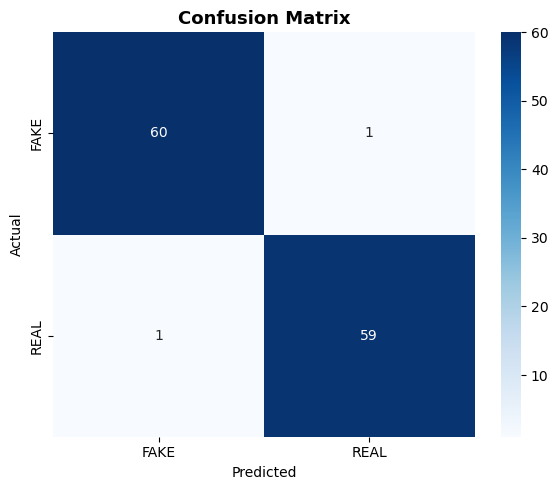

 Saved: confusion_matrix.png


In [27]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # probability of REAL

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_prob)


print(' MODEL EVALUATION')

print(f'  Accuracy    : {accuracy * 100:.2f}%')
print(f'  ROC-AUC     : {roc_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['FAKE', 'REAL']))

# Confusion Matrix Plot 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()
print(' Saved: confusion_matrix.png')

## Step 10: Save Model & Scaler

In [28]:
joblib.dump(model,  'audio_model.joblib')
joblib.dump(scaler, 'audio_scaler.joblib')

print(' Model  saved → audio_model.joblib')
print(' Scaler saved → audio_scaler.joblib')
print()
print('   To load later:')
print('   model  = joblib.load("audio_model.joblib")')
print('   scaler = joblib.load("audio_scaler.joblib")')

 Model  saved → audio_model.joblib
 Scaler saved → audio_scaler.joblib

   To load later:
   model  = joblib.load("audio_model.joblib")
   scaler = joblib.load("audio_scaler.joblib")


## Step 11: Predict on New Audio Files

In [29]:
def predict_audio(filename):
    """
    Predicts whether an audio file is REAL or FAKE.
    Searches in: current folder → AUDIO/REAL → AUDIO/FAKE
    
    Parameters:
        filename : just the filename (e.g. 'obama.wav') OR full path
    
    Returns:
        dict with verdict, confidence, and label
    """
    search_dirs = [
        '',                         
        os.path.join('AUDIO', 'REAL'),
        os.path.join('AUDIO', 'FAKE'),
    ]

    resolved_path = None
    for d in search_dirs:
        candidate = os.path.join(d, filename) if d else filename
        if os.path.exists(candidate):
            resolved_path = candidate
            break

    if resolved_path is None:
        print(f' File not found: {filename}')
        return None

    print(f' File     : {resolved_path}')

    #  Extract features 
    features = extract_features(resolved_path)
    if features is None:
        print(' Could not extract features from file.')
        return None

    # Normalize & predict
    features_scaled = scaler.transform([features])
    prediction      = model.predict(features_scaled)[0]
    probabilities   = model.predict_proba(features_scaled)[0]

    fake_conf = probabilities[0] * 100   # confidence it's FAKE
    real_conf = probabilities[1] * 100   # confidence it's REAL

    print(f' Result   : {" REAL AUDIO" if prediction == 1 else " FAKE / AI GENERATED"}')
    print(f' Real     : {real_conf:.1f}%')
    print(f' Fake     : {fake_conf:.1f}%')

    return {
        'file':       resolved_path,
        'verdict':    'REAL' if prediction == 1 else 'FAKE',
        'is_fake':    prediction == 0,
        'real_conf':  round(real_conf, 1),
        'fake_conf':  round(fake_conf, 1),
    }


print(' predict_audio() function ready!')

 predict_audio() function ready!


## Step 12: Test Predictions

In [30]:
# Test on known files 
test_files = [
    'obama-original.wav',
    'trump-original.wav',
    'musk-original.wav',
    'linus-original.wav',
    'margot-original.wav',
    'ryan-original.wav',
    'musk-to-biden.wav',
    'Recording (1).wav',
]


print(' BATCH PREDICTION TEST')


for f in test_files:
    print(f'\n── {f} ──')
    predict_audio(f)

 BATCH PREDICTION TEST

── obama-original.wav ──
 File     : AUDIO\REAL\obama-original.wav
 Result   :  REAL AUDIO
 Real     : 99.1%
 Fake     : 0.9%

── trump-original.wav ──
 File     : AUDIO\REAL\trump-original.wav
 Result   :  REAL AUDIO
 Real     : 92.7%
 Fake     : 7.3%

── musk-original.wav ──
 File     : AUDIO\REAL\musk-original.wav
 Result   :  REAL AUDIO
 Real     : 97.8%
 Fake     : 2.2%

── linus-original.wav ──
 File     : AUDIO\REAL\linus-original.wav
 Result   :  REAL AUDIO
 Real     : 92.6%
 Fake     : 7.4%

── margot-original.wav ──
 File     : AUDIO\REAL\margot-original.wav
 Result   :  REAL AUDIO
 Real     : 99.2%
 Fake     : 0.8%

── ryan-original.wav ──
 File     : AUDIO\REAL\ryan-original.wav
 Result   :  REAL AUDIO
 Real     : 99.5%
 Fake     : 0.5%

── musk-to-biden.wav ──
 File     : AUDIO\FAKE\musk-to-biden.wav
 Result   :  FAKE / AI GENERATED
 Real     : 0.5%
 Fake     : 99.5%

── Recording (1).wav ──
 File     : AUDIO\REAL\Recording (1).wav
 Result   :  REAL

In [31]:
result = predict_audio('Recording (7).wav')

 File     : AUDIO\REAL\Recording (7).wav
 Result   :  REAL AUDIO
 Real     : 99.1%
 Fake     : 0.9%


### Small UI

In [32]:
import ipywidgets as widgets
from IPython.display import display, Audio
import numpy as np
import librosa

def extract_features(file_path):
    audio, sr = librosa.load(file_path, res_type='kaiser_fast')
    mfccs = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T, axis=0)
    return mfccs

upload = widgets.FileUpload(
    accept='.wav,.mp3',
    multiple=False
)

predict_btn = widgets.Button(
    description="Predict",
    button_style='success'
)

output = widgets.Output()


def on_predict_click(b):
    with output:
        output.clear_output()

        if not upload.value:
            print(" Please upload an audio file first!")
            return

        # Get uploaded file
        file_info = upload.value[0]
        file_content = file_info['content']
        # Save temp file
        with open("temp_audio.wav", "wb") as f:
            f.write(file_content)

        # Play audio
        display(Audio("temp_audio.wav"))

        # Extract features
        features = extract_features("temp_audio.wav")
        features = features.reshape(1, -1)

        # Predict
        prediction = model.predict(features)

        # Handle output (depends on your model)
        if prediction[0] > 0.5:
            print(" Fake Audio Detected")
        else:
            print(" Real Audio")


predict_btn.on_click(on_predict_click)


display(widgets.VBox([
    widgets.Label(" Upload Audio File"),
    upload,
    predict_btn,
    output
]))